## 1. Create a straight line dataset using the linear regression formula (weight * X + bias).

- Create a straight line dataset using the linear regression formula (weight * X + bias).
- Set weight=0.3 and bias=0.9 there should be at least 100 datapoints total.
- Split the data into 80% training, 20% testing.
- Plot the training and testing data so it becomes visual.

In [29]:
import torch
import matplotlib.pyplot as plt

In [30]:
weight = 0.3
bias = 0.9
# y=0.3x + 0.9

In [31]:
start = 0
end = 1
step = 0.01

In [32]:
X = torch.arange(start,end,step).unsqueeze(dim=1)
print(len(X))

100


In [33]:
# create the labels 
y = weight * X + bias

In [34]:
# train test split
train_split = int(0.8*len(X))
X_train = X[:train_split]
y_train = y[:train_split]

X_test = X[train_split:]
y_test = y[train_split:]
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

80
20
80
20


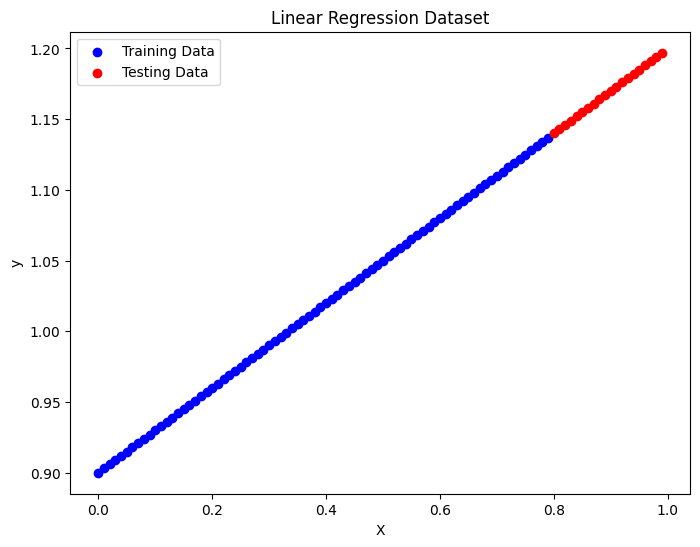

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(X_train, y_train, color="blue", label="Training Data")

plt.scatter(X_test, y_test, color="red", label="Testing Data")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Dataset")

plt.legend()

plt.show()

## Build a PyTorch model by subclassing nn.Module.

- Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.
- Implement the forward() method to compute the linear regression function you used to create the dataset in 1.
- Once you've constructed the model, make an instance of it and check its state_dict().
- Note: If you'd like to use nn.Linear() instead of nn.Parameter() you can.



In [36]:
from torch import nn

In [37]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__() # initializes the parent nn.Module
        self.weights = nn.Parameter(torch.randn(1),requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1),requires_grad=True)
    def forward(self,x):
        return self.weights * x + self.bias
    

In [38]:
model = LinearRegressionModel()

In [39]:
print(model.state_dict())

OrderedDict({'weights': tensor([-1.2401]), 'bias': tensor([-1.5674])})


## 3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.

- Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
- Write a training loop to perform the appropriate training steps for 300 epochs.
- The training loop should test the model on the test dataset every 20 epochs.

In [40]:
loss_fn = nn.L1Loss()

In [41]:
optimizer = torch.optim.SGD(params=model.parameters(),lr =0.01)

In [47]:
epochs = 300
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        model.eval()
        with torch.inference_mode():
            test_pred = model(X_test)
            test_loss = loss_fn(test_pred,y_test)
            print(
            f"Epoch: {epoch} | "
            f"Train Loss: {loss:.4f} | "
            f"Test Loss: {test_loss:.4f}"
        )

Epoch: 0 | Train Loss: 0.0826 | Test Loss: 0.2016
Epoch: 20 | Train Loss: 0.0755 | Test Loss: 0.1777
Epoch: 40 | Train Loss: 0.0687 | Test Loss: 0.1613
Epoch: 60 | Train Loss: 0.0618 | Test Loss: 0.1454
Epoch: 80 | Train Loss: 0.0549 | Test Loss: 0.1290
Epoch: 100 | Train Loss: 0.0481 | Test Loss: 0.1127
Epoch: 120 | Train Loss: 0.0412 | Test Loss: 0.0967
Epoch: 140 | Train Loss: 0.0344 | Test Loss: 0.0804
Epoch: 160 | Train Loss: 0.0275 | Test Loss: 0.0641
Epoch: 180 | Train Loss: 0.0207 | Test Loss: 0.0481
Epoch: 200 | Train Loss: 0.0138 | Test Loss: 0.0318
Epoch: 220 | Train Loss: 0.0070 | Test Loss: 0.0158
Epoch: 240 | Train Loss: 0.0074 | Test Loss: 0.0035
Epoch: 260 | Train Loss: 0.0074 | Test Loss: 0.0035
Epoch: 280 | Train Loss: 0.0074 | Test Loss: 0.0035


## Make predictions with the trained model on the test data.

- Visualize these predictions against the original training and testing data (note: you may need to make sure the predictions are not on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [48]:
model.eval()

LinearRegressionModel()

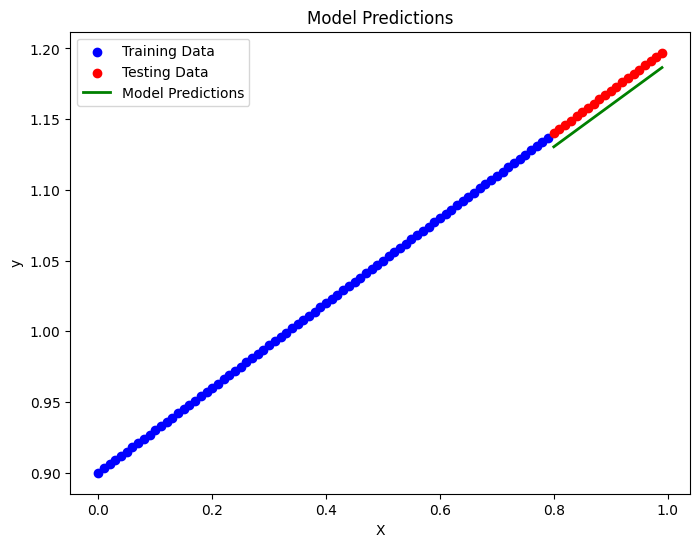

In [49]:
with torch.inference_mode():
    y_preds = model(X_test)

# Move tensors to CPU if needed and flatten them for plotting
X_train_plot = X_train.squeeze().cpu()
y_train_plot = y_train.squeeze().cpu()
X_test_plot = X_test.squeeze().cpu()
y_test_plot = y_test.squeeze().cpu()
y_preds_plot = y_preds.squeeze().cpu()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(X_train_plot, y_train_plot, color="blue", label="Training Data")
plt.scatter(X_test_plot, y_test_plot, color="red", label="Testing Data")
plt.plot(X_test_plot, y_preds_plot, color="green", label="Model Predictions", linewidth=2)

plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("Model Predictions")

plt.show()

In [50]:
print(model.state_dict())

OrderedDict({'weights': tensor([0.2948]), 'bias': tensor([0.8946])})


## 5. Save your trained model's state_dict() to file.

- Create a new instance of your model class you made in 2. and load in the state_dict() you just saved to it.
- Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [51]:
MODEL_PATH = "linear_regression_model.pth"

torch.save(model.state_dict(), MODEL_PATH)

In [52]:
loaded_model = LinearRegressionModel()

In [53]:
loaded_model.load_state_dict(torch.load(MODEL_PATH))

<All keys matched successfully>

In [54]:
loaded_model.eval()

LinearRegressionModel()

In [55]:
with torch.inference_mode():
    loaded_preds = loaded_model(X_test)

In [56]:
print(torch.equal(y_preds, loaded_preds))

True


In [57]:
print(y_preds[:5])
print(loaded_preds[:5])

tensor([[1.1305],
        [1.1334],
        [1.1364],
        [1.1393],
        [1.1423]])
tensor([[1.1305],
        [1.1334],
        [1.1364],
        [1.1393],
        [1.1423]])
